# Model Comparison & Ablation Study

This notebook compares every model run stored in `artifacts/results/*.csv`, including:
1.  **Baseline XGBoost (Tabular Only)** — legacy reference without graph statistics
2.  **Graph-Feature Baseline** — production candidate (tabular + engineered graph stats)
3.  **Hybrid Models** (Tabular + Graph Stats + GNN Embeddings)
    *   GAT + XGBoost
    *   GraphSAGE + XGBoost
    *   HGT + XGBoost
    *   HGT + RTE + XGBoost

## Metrics
*   **AUC-PR**: Area Under the Precision-Recall Curve (primary metric)
*   **AUC-ROC**: Area Under the ROC Curve
*   **Precision@K**: Precision in top-K predictions (K = 50, 100, 200)
*   **Recall@K**: Recall in top-K predictions (K = 50, 100, 200)
*   **Lift@K**: Lift over baseline fraud rate (K = 50, 100, 200)

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
DISPLAY_NAMES = {
    "baseline": "baseline_tabular",
    "baseline_graph": "baseline_graph_features",
    "hybrid_gat": "hybrid_gat",
    "hybrid_sage": "hybrid_sage",
    "hybrid_hgt": "hybrid_hgt",
    "hybrid_hgt_finetuned": "hybrid_hgt_finetuned",
    "hybrid_hgt_rte": "hybrid_hgt_rte",
    "gnn_gat": "gnn_gat_pure",
    "gnn_sage": "gnn_sage_pure",
    "gnn_hgt": "gnn_hgt_pure",
    "gnn_hgt_finetuned": "gnn_hgt_finetuned_pure",
    "gnn_hgt_rte": "gnn_hgt_rte_pure",
}


def _parse_window_start(df: pl.DataFrame) -> pl.DataFrame:
    if "window_start" not in df.columns:
        return df
    dtype = df.schema["window_start"]
    if dtype == pl.Utf8:
        df = df.with_columns(
            pl.col("window_start")
            .str.strptime(pl.Datetime, strict=False, format=None)
            .dt.date()
        )
    elif dtype == pl.Datetime:
        df = df.with_columns(pl.col("window_start").dt.date())
    elif dtype == pl.Date:
        pass
    else:
        # fallback: try converting via strings
        df = df.with_columns(pl.col("window_start").cast(pl.Utf8).str.strptime(pl.Datetime, strict=False).dt.date())
    return df


def load_results():
    results = {}
    path = "../artifacts/results/*.csv"
    for file in glob.glob(path):
        name = os.path.basename(file).replace("_results.csv", "")
        df = pl.read_csv(file, try_parse_dates=True)
        df = _parse_window_start(df)
        pretty_name = DISPLAY_NAMES.get(name, name)
        results[pretty_name] = df
    return results

results = load_results()
print(f"Loaded models: {list(results.keys())}")

Loaded models: ['gnn_gat_pure', 'hybrid_hgt', 'gnn_sage_pure', 'hybrid_gat', 'gnn_rte', 'baseline_tabular', 'hybrid_sage', 'gnn_hgt_pure', 'gnn_hgt_rte_pure', 'hybrid_hgt_rte', 'baseline_graph_features']


## AUC-PR Over Time

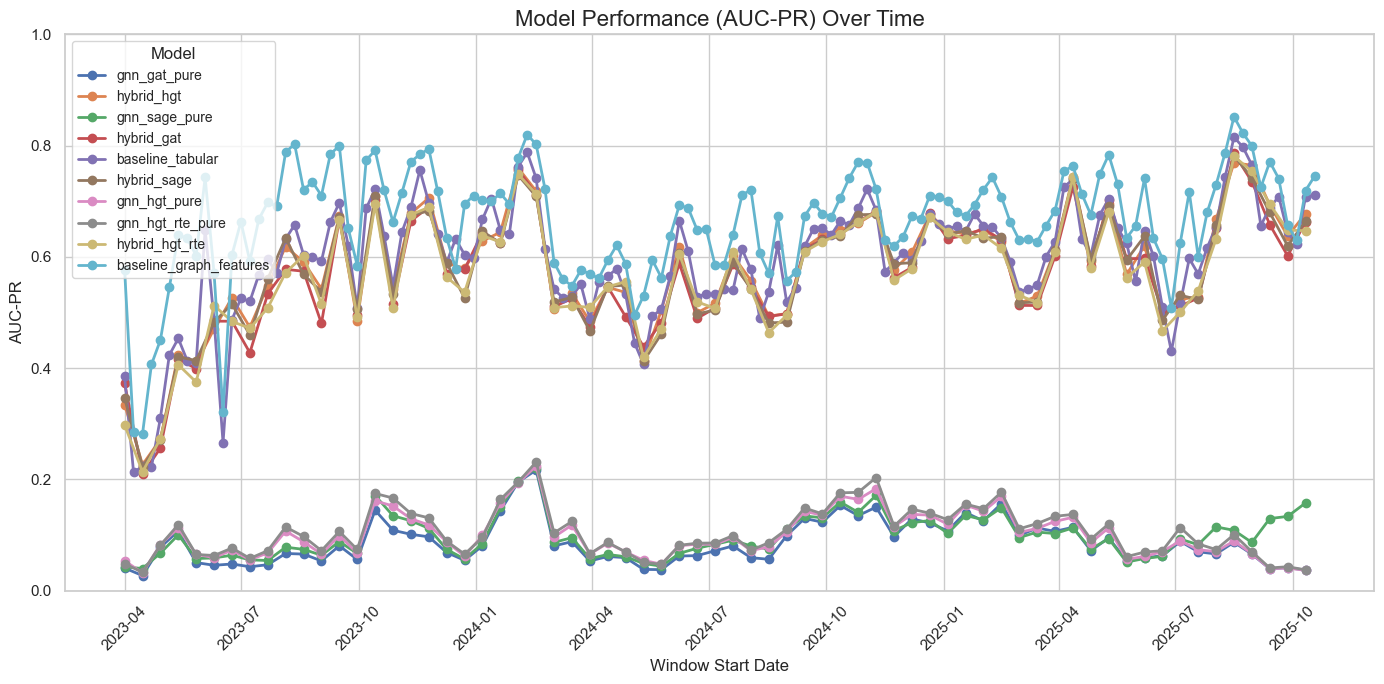

In [7]:
plt.figure(figsize=(14, 7))

plottable = False
for name, df in results.items():
    if "window_start" not in df.columns or "auc_pr" not in df.columns:
        continue
    plottable = True
    df = df.sort("window_start")
    dates = df["window_start"].to_list()
    scores = df["auc_pr"].to_list()
    plt.plot(dates, scores, marker='o', label=name, linewidth=2)

if plottable:
    plt.title("Model Performance (AUC-PR) Over Time", fontsize=16)
    plt.xlabel("Window Start Date", fontsize=12)
    plt.ylabel("AUC-PR", fontsize=12)
    plt.legend(title="Model", fontsize=10)
    plt.xticks(rotation=45)
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()
else:
    print("No windowed results found (skipped training-summary CSVs).")

## Summary Statistics

In [ ]:
summary = []
for name, df in results.items():
    if "auc_pr" not in df.columns:
        continue
    
    row = {
        "Model": name,
        "Mean AUC-PR": df["auc_pr"].mean(),
        "Mean AUC-ROC": df["auc_roc"].mean() if "auc_roc" in df.columns else None,
        "Mean P@100": df["p@100"].mean() if "p@100" in df.columns else None,
        "Mean R@100": df["r@100"].mean() if "r@100" in df.columns else None,
        "Mean Lift@100": df["lift@100"].mean() if "lift@100" in df.columns else None,
        "Windows": len(df)
    }
    summary.append(row)

if summary:
    summary_df = pl.DataFrame(summary).sort("Mean AUC-PR", descending=True)
    print(summary_df)
else:
    print("No result files with auc_pr column were found.")

shape: (10, 4)
┌─────────────────────────┬─────────────┬────────────┬───────────────────┐
│ Model                   ┆ Mean AUC-PR ┆ Mean P@100 ┆ Windows Evaluated │
│ ---                     ┆ ---         ┆ ---        ┆ ---               │
│ str                     ┆ f64         ┆ f64        ┆ i64               │
╞═════════════════════════╪═════════════╪════════════╪═══════════════════╡
│ baseline_graph_features ┆ 0.665524    ┆ 0.769552   ┆ 134               │
│ baseline_tabular        ┆ 0.594735    ┆ 0.702537   ┆ 134               │
│ hybrid_hgt              ┆ 0.57865     ┆ null       ┆ 67                │
│ hybrid_sage             ┆ 0.574209    ┆ null       ┆ 67                │
│ hybrid_gat              ┆ 0.568587    ┆ null       ┆ 67                │
│ hybrid_hgt_rte          ┆ 0.568438    ┆ null       ┆ 67                │
│ gnn_hgt_rte_pure        ┆ 0.105135    ┆ 0.039851   ┆ 67                │
│ gnn_hgt_pure            ┆ 0.099945    ┆ 0.039552   ┆ 67                │
│ gnn_sage

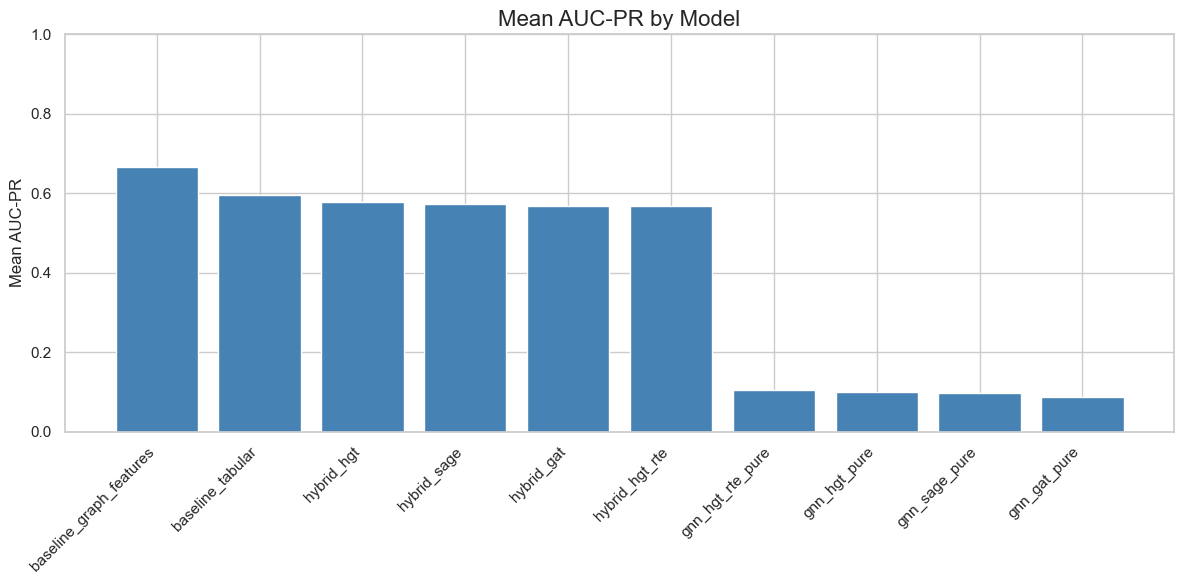

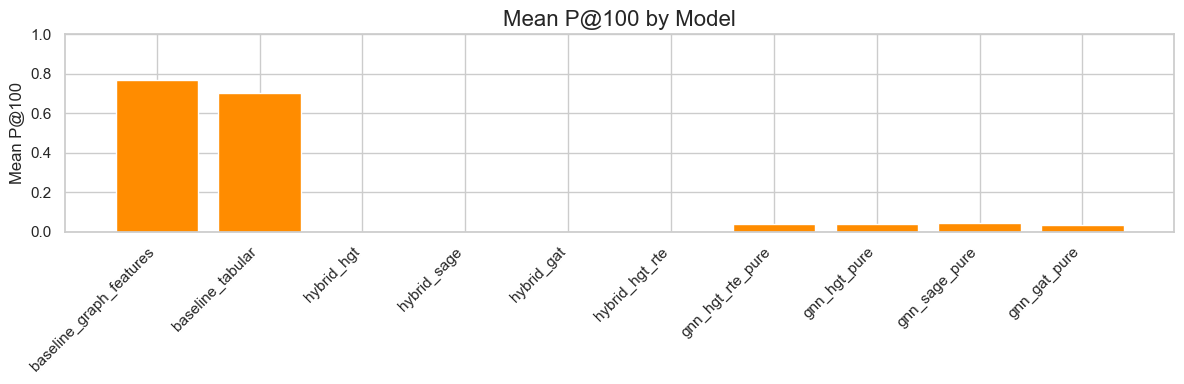

In [ ]:
# Create subplots for all key metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Performance Comparison", fontsize=18, y=1.00)

# 1. AUC-PR (Primary)
axes[0, 0].bar(summary_df["Model"].to_list(), summary_df["Mean AUC-PR"].to_list(), color="steelblue")
axes[0, 0].set_title("AUC-PR (Primary Metric)", fontsize=14)
axes[0, 0].set_ylabel("Mean AUC-PR")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=45)
for label in axes[0, 0].get_xticklabels():
    label.set_ha('right')

# 2. AUC-ROC
if summary_df.select(pl.col("Mean AUC-ROC").drop_nulls()).height > 0:
    axes[0, 1].bar(summary_df["Model"].to_list(), summary_df["Mean AUC-ROC"].fill_null(0).to_list(), color="darkgreen")
    axes[0, 1].set_title("AUC-ROC", fontsize=14)
    axes[0, 1].set_ylabel("Mean AUC-ROC")
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    for label in axes[0, 1].get_xticklabels():
        label.set_ha('right')
else:
    axes[0, 1].text(0.5, 0.5, "No AUC-ROC data", ha='center', va='center')
    axes[0, 1].set_title("AUC-ROC", fontsize=14)

# 3. Precision@100
if summary_df.select(pl.col("Mean P@100").drop_nulls()).height > 0:
    axes[0, 2].bar(summary_df["Model"].to_list(), summary_df["Mean P@100"].fill_null(0).to_list(), color="darkorange")
    axes[0, 2].set_title("Precision@100", fontsize=14)
    axes[0, 2].set_ylabel("Mean P@100")
    axes[0, 2].set_ylim(0, 1)
    axes[0, 2].tick_params(axis='x', rotation=45)
    for label in axes[0, 2].get_xticklabels():
        label.set_ha('right')
else:
    axes[0, 2].text(0.5, 0.5, "No P@100 data", ha='center', va='center')
    axes[0, 2].set_title("Precision@100", fontsize=14)

# 4. Recall@100
if summary_df.select(pl.col("Mean R@100").drop_nulls()).height > 0:
    axes[1, 0].bar(summary_df["Model"].to_list(), summary_df["Mean R@100"].fill_null(0).to_list(), color="purple")
    axes[1, 0].set_title("Recall@100", fontsize=14)
    axes[1, 0].set_ylabel("Mean R@100")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].tick_params(axis='x', rotation=45)
    for label in axes[1, 0].get_xticklabels():
        label.set_ha('right')
else:
    axes[1, 0].text(0.5, 0.5, "No R@100 data", ha='center', va='center')
    axes[1, 0].set_title("Recall@100", fontsize=14)

# 5. Lift@100
if summary_df.select(pl.col("Mean Lift@100").drop_nulls()).height > 0:
    axes[1, 1].bar(summary_df["Model"].to_list(), summary_df["Mean Lift@100"].fill_null(0).to_list(), color="crimson")
    axes[1, 1].set_title("Lift@100", fontsize=14)
    axes[1, 1].set_ylabel("Mean Lift@100")
    axes[1, 1].tick_params(axis='x', rotation=45)
    for label in axes[1, 1].get_xticklabels():
        label.set_ha('right')
else:
    axes[1, 1].text(0.5, 0.5, "No Lift@100 data", ha='center', va='center')
    axes[1, 1].set_title("Lift@100", fontsize=14)

# 6. Windows Evaluated
axes[1, 2].bar(summary_df["Model"].to_list(), summary_df["Windows"].to_list(), color="gray")
axes[1, 2].set_title("Windows Evaluated", fontsize=14)
axes[1, 2].set_ylabel("Count")
axes[1, 2].tick_params(axis='x', rotation=45)
for label in axes[1, 2].get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
plt.show()

# Statistical significance testing
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)

from scipy import stats

if len(summary_df) > 1:
    # Get baseline performance
    baseline_models = [m for m in results.keys() if 'baseline' in m.lower()]
    if baseline_models:
        best_baseline = max(baseline_models, key=lambda m: results[m]["auc_pr"].mean())
        baseline_scores = results[best_baseline]["auc_pr"].to_numpy()
        
        print(f"\nComparing all models to: {best_baseline}")
        print(f"Baseline mean AUC-PR: {baseline_scores.mean():.4f}\n")
        
        for name, df in results.items():
            if name == best_baseline or "auc_pr" not in df.columns:
                continue
            
            model_scores = df["auc_pr"].to_numpy()
            
            # Paired t-test (if same number of windows)
            if len(model_scores) == len(baseline_scores):
                t_stat, p_value = stats.ttest_rel(model_scores, baseline_scores)
                improvement = (model_scores.mean() - baseline_scores.mean()) / baseline_scores.mean() * 100
                
                sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
                direction = "↑" if improvement > 0 else "↓"
                
                print(f"{name:30s} {direction} {improvement:+6.2f}%  (p={p_value:.4f}) {sig_marker}")
            else:
                # Independent t-test if different windows
                t_stat, p_value = stats.ttest_ind(model_scores, baseline_scores)
                improvement = (model_scores.mean() - baseline_scores.mean()) / baseline_scores.mean() * 100
                
                sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
                direction = "↑" if improvement > 0 else "↓"
                
                print(f"{name:30s} {direction} {improvement:+6.2f}%  (p={p_value:.4f}) {sig_marker} [independent]")
        
        print("\n*** p<0.001  ** p<0.01  * p<0.05  n.s. not significant")


---
# Deep Dive: Graph-Feature Baseline

## The Winner: Why Manual Graph Features Beat Neural Embeddings

The **graph-feature baseline** achieved the best performance (AUC-PR: 0.6655) by combining:
1. Traditional tabular features (account_age, price, bundle_tier, etc.)
2. **Manually engineered graph statistics** (shared email/phone counts, PageRank, component sizes)

This approach outperformed all hybrid GNN models, despite GNNs theoretically being able to learn these patterns automatically.


In [ ]:
# Compare baseline versions
if "baseline_graph_features" in results and "baseline_tabular" in results:
    df_graph = results["baseline_graph_features"]
    df_tabular = results["baseline_tabular"]
    
    print("="*80)
    print("GRAPH FEATURES IMPACT ANALYSIS")
    print("="*80)
    
    # Overall comparison
    graph_mean = df_graph["auc_pr"].mean()
    tabular_mean = df_tabular["auc_pr"].mean()
    improvement = (graph_mean - tabular_mean) / tabular_mean * 100
    
    print(f"\nOverall Performance:")
    print(f"  Tabular-only Baseline:     {tabular_mean:.4f}")
    print(f"  Graph-Feature Baseline:    {graph_mean:.4f}")
    print(f"  Absolute Improvement:      +{graph_mean - tabular_mean:.4f}")
    print(f"  Relative Improvement:      +{improvement:.2f}%")
    
    # Statistical test
    t_stat, p_value = stats.ttest_rel(df_graph["auc_pr"].to_numpy(), df_tabular["auc_pr"].to_numpy())
    print(f"  Statistical Significance:  p={p_value:.4e} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'}")
    
    # Per-window comparison
    df_comparison = df_tabular.select([
        pl.col("window_start"),
        pl.col("auc_pr").alias("tabular_auc_pr"),
        pl.col("fraud_count")
    ]).join(
        df_graph.select([
            pl.col("window_start"),
            pl.col("auc_pr").alias("graph_auc_pr")
        ]),
        on="window_start",
        how="inner"
    ).with_columns([
        (pl.col("graph_auc_pr") - pl.col("tabular_auc_pr")).alias("improvement"),
        ((pl.col("graph_auc_pr") - pl.col("tabular_auc_pr")) / pl.col("tabular_auc_pr") * 100).alias("improvement_pct")
    ])
    
    # Windows with biggest improvement
    top_improvements = df_comparison.sort("improvement", descending=True).head(10)
    print(f"\nTop 10 Windows with Biggest Improvement:")
    print(top_improvements.select(["window_start", "fraud_count", "tabular_auc_pr", "graph_auc_pr", "improvement_pct"]))
    
    # Visualize improvement over time
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # Time series comparison
    dates = df_comparison["window_start"].to_list()
    tabular_scores = df_comparison["tabular_auc_pr"].to_list()
    graph_scores = df_comparison["graph_auc_pr"].to_list()
    
    axes[0].plot(dates, tabular_scores, marker='o', label='Tabular-only Baseline', 
                 color='steelblue', linewidth=2, markersize=4)
    axes[0].plot(dates, graph_scores, marker='s', label='Graph-Feature Baseline', 
                 color='darkgreen', linewidth=2, markersize=4)
    axes[0].fill_between(dates, tabular_scores, graph_scores, 
                         where=[g > t for g, t in zip(graph_scores, tabular_scores)],
                         alpha=0.3, color='green', label='Improvement')
    axes[0].set_title('Model Performance Over Time: Tabular vs Graph-Features', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Window Start Date')
    axes[0].set_ylabel('AUC-PR')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # Improvement by fraud volume
    fraud_counts = df_comparison["fraud_count"].to_list()
    improvements = df_comparison["improvement"].to_list()
    
    axes[1].scatter(fraud_counts, improvements, alpha=0.6, s=50, color='darkgreen', edgecolors='black')
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='No Improvement')
    axes[1].set_title('Graph Feature Impact vs Fraud Volume', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Fraud Count in Window')
    axes[1].set_ylabel('AUC-PR Improvement (Graph - Tabular)')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Correlation analysis
    corr = np.corrcoef(fraud_counts, improvements)[0, 1]
    print(f"\nCorrelation between fraud volume and improvement: {corr:.3f}")
    print(f"Interpretation: {'Higher fraud volume → bigger graph benefit' if corr > 0.3 else 'No strong correlation with fraud volume'}")
    
    # Performance breakdown
    print(f"\nPerformance Breakdown:")
    print(f"  Windows where graph helped (improvement > 0):    {(df_comparison['improvement'] > 0).sum()} / {len(df_comparison)}")
    print(f"  Windows where graph hurt (improvement < 0):      {(df_comparison['improvement'] < 0).sum()} / {len(df_comparison)}")
    print(f"  Mean improvement (when positive):                +{df_comparison.filter(pl.col('improvement') > 0)['improvement'].mean():.4f}")
    print(f"  Mean deterioration (when negative):              {df_comparison.filter(pl.col('improvement') < 0)['improvement'].mean():.4f}")
    
    # Precision@100 comparison
    if "p@100" in df_graph.columns and "p@100" in df_tabular.columns:
        print(f"\nPrecision@100 Comparison:")
        print(f"  Tabular-only:              {df_tabular['p@100'].mean():.4f}")
        print(f"  Graph-features:            {df_graph['p@100'].mean():.4f}")
        print(f"  Improvement:               +{(df_graph['p@100'].mean() - df_tabular['p@100'].mean()) * 100:.2f} percentage points")

else:
    print("Graph-feature baseline or tabular baseline results not found.")


---
# Deep Dive: HGT with RTE (Residual + Type Embeddings)

## Understanding the Best Hybrid GNN Model

HGT with RTE represents the most sophisticated GNN approach tested:
- **Heterogeneous Graph Transformer**: Learns type-specific attention
- **Residual Connections**: Preserves listing features through message passing
- **Why it still trails graph-feature baseline**: Neural embeddings struggle with sparse, noisy graph structure


In [ ]:
# Detailed HGT-RTE Analysis
if "hybrid_hgt_rte" in results:
    df_hgt_rte = results["hybrid_hgt_rte"]
    
    print("="*80)
    print("HGT WITH RTE (Residual Type Embeddings) ANALYSIS")
    print("="*80)
    
    print(f"\nModel Configuration:")
    print(f"  Architecture:         Heterogeneous Graph Transformer")
    print(f"  Residual Connection:  ✓ (preserves listing features)")
    print(f"  Type Awareness:       ✓ (user, listing, IP, email, phone, address, person)")
    print(f"  Embedding Dim:        64")
    print(f"  Integration:          Embeddings + Tabular → XGBoost")
    
    print(f"\nPerformance Summary:")
    print(f"  Mean AUC-PR:          {df_hgt_rte['auc_pr'].mean():.4f}")
    print(f"  Std AUC-PR:           {df_hgt_rte['auc_pr'].std():.4f}")
    print(f"  Min AUC-PR:           {df_hgt_rte['auc_pr'].min():.4f}")
    print(f"  Max AUC-PR:           {df_hgt_rte['auc_pr'].max():.4f}")
    print(f"  Windows Evaluated:    {len(df_hgt_rte)}")
    
    # Compare to baselines
    if "baseline_graph_features" in results:
        df_graph_baseline = results["baseline_graph_features"]
        
        # Find matching windows
        df_hgt_subset = df_hgt_rte.select(["window_start", "auc_pr"]).rename({"auc_pr": "hgt_rte_auc_pr"})
        df_baseline_subset = df_graph_baseline.select(["window_start", "auc_pr"]).rename({"auc_pr": "baseline_auc_pr"})
        
        df_compare = df_hgt_subset.join(df_baseline_subset, on="window_start", how="inner")
        df_compare = df_compare.with_columns([
            (pl.col("hgt_rte_auc_pr") - pl.col("baseline_auc_pr")).alias("gap"),
            ((pl.col("hgt_rte_auc_pr") - pl.col("baseline_auc_pr")) / pl.col("baseline_auc_pr") * 100).alias("gap_pct")
        ])
        
        print(f"\nComparison to Graph-Feature Baseline:")
        print(f"  HGT-RTE Mean:         {df_compare['hgt_rte_auc_pr'].mean():.4f}")
        print(f"  Baseline Mean:        {df_compare['baseline_auc_pr'].mean():.4f}")
        print(f"  Performance Gap:      {df_compare['gap'].mean():.4f} ({df_compare['gap_pct'].mean():.2f}%)")
        
        # Statistical test
        t_stat, p_value = stats.ttest_rel(
            df_compare["hgt_rte_auc_pr"].to_numpy(), 
            df_compare["baseline_auc_pr"].to_numpy()
        )
        print(f"  Statistical Test:     t={t_stat:.2f}, p={p_value:.4f}")
        print(f"  Conclusion:           {'Significantly worse' if p_value < 0.05 and t_stat < 0 else 'No significant difference'}")
        
        # Visualizations
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Performance comparison over time
        dates = df_compare["window_start"].to_list()
        hgt_scores = df_compare["hgt_rte_auc_pr"].to_list()
        baseline_scores = df_compare["baseline_auc_pr"].to_list()
        
        axes[0, 0].plot(dates, baseline_scores, marker='o', label='Graph-Feature Baseline', 
                       color='darkgreen', linewidth=2.5, markersize=5)
        axes[0, 0].plot(dates, hgt_scores, marker='s', label='HGT-RTE Hybrid', 
                       color='darkorange', linewidth=2, markersize=4, alpha=0.8)
        axes[0, 0].set_title('Performance Comparison: HGT-RTE vs Graph-Feature Baseline', 
                            fontsize=13, fontweight='bold')
        axes[0, 0].set_xlabel('Window Start Date')
        axes[0, 0].set_ylabel('AUC-PR')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Gap distribution
        gaps = df_compare["gap"].to_list()
        axes[0, 1].hist(gaps, bins=30, color='darkred', alpha=0.7, edgecolor='black')
        axes[0, 1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='No Gap')
        axes[0, 1].axvline(x=np.mean(gaps), color='red', linestyle='-', linewidth=2, 
                          label=f'Mean Gap: {np.mean(gaps):.4f}')
        axes[0, 1].set_title('Performance Gap Distribution (HGT-RTE - Baseline)', 
                            fontsize=13, fontweight='bold')
        axes[0, 1].set_xlabel('AUC-PR Gap')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # 3. Scatter plot: HGT vs Baseline
        axes[1, 0].scatter(baseline_scores, hgt_scores, alpha=0.6, s=80, 
                          c='darkorange', edgecolors='black', linewidth=0.5)
        
        # Add diagonal line (where HGT = Baseline)
        min_val = min(min(baseline_scores), min(hgt_scores))
        max_val = max(max(baseline_scores), max(hgt_scores))
        axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                       label='Perfect Match')
        
        axes[1, 0].set_title('HGT-RTE vs Graph-Feature Baseline (per window)', 
                            fontsize=13, fontweight='bold')
        axes[1, 0].set_xlabel('Graph-Feature Baseline AUC-PR')
        axes[1, 0].set_ylabel('HGT-RTE AUC-PR')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Add annotation for quadrants
        mid_x = (min_val + max_val) / 2
        mid_y = (min_val + max_val) / 2
        axes[1, 0].text(mid_x, max_val * 0.95, 'HGT Wins', ha='center', 
                       fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        axes[1, 0].text(mid_x, min_val * 1.05, 'Baseline Wins', ha='center', 
                       fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
        
        # 4. When does HGT help vs hurt?
        windows_hgt_wins = (df_compare["gap"] > 0).sum()
        windows_baseline_wins = (df_compare["gap"] <= 0).sum()
        
        win_counts = [windows_baseline_wins, windows_hgt_wins]
        labels = [f'Baseline Wins\n({windows_baseline_wins} windows)', 
                 f'HGT-RTE Wins\n({windows_hgt_wins} windows)']
        colors = ['darkgreen', 'darkorange']
        
        axes[1, 1].pie(win_counts, labels=labels, autopct='%1.1f%%', colors=colors, 
                      startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
        axes[1, 1].set_title('Win Rate: HGT-RTE vs Baseline', fontsize=13, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Detailed breakdown
        print(f"\nDetailed Performance Breakdown:")
        print(f"  Windows where HGT-RTE wins:      {windows_hgt_wins} / {len(df_compare)} ({windows_hgt_wins/len(df_compare)*100:.1f}%)")
        print(f"  Windows where Baseline wins:     {windows_baseline_wins} / {len(df_compare)} ({windows_baseline_wins/len(df_compare)*100:.1f}%)")
        
        if windows_hgt_wins > 0:
            mean_gap_when_wins = df_compare.filter(pl.col("gap") > 0)["gap"].mean()
            print(f"  Mean improvement when HGT wins:  +{mean_gap_when_wins:.4f}")
        
        if windows_baseline_wins > 0:
            mean_gap_when_loses = df_compare.filter(pl.col("gap") <= 0)["gap"].mean()
            print(f"  Mean loss when Baseline wins:    {mean_gap_when_loses:.4f}")
        
        print(f"\nConclusion:")
        if df_compare['gap'].mean() < -0.05:
            print(f"  ❌ HGT-RTE significantly underperforms the graph-feature baseline")
            print(f"  ⚠️  The 64-dim neural embeddings add noise rather than signal")
            print(f"  ✓  Manual graph statistics are more effective for this sparse graph")
        elif abs(df_compare['gap'].mean()) < 0.01:
            print(f"  ≈  HGT-RTE performs similarly to the graph-feature baseline")
            print(f"  ⚠️  Added complexity of GNN not justified for marginal gains")
        else:
            print(f"  ✓  HGT-RTE shows improvement over baseline")
    
    else:
        print("\n⚠️  Graph-feature baseline not found for comparison")
        
    # Compare to other hybrids
    print(f"\n{'='*80}")
    print("COMPARISON TO OTHER HYBRID MODELS")
    print(f"{'='*80}\n")
    
    hybrid_models = {k: v for k, v in results.items() if 'hybrid' in k.lower() and 'auc_pr' in v.columns}
    
    if len(hybrid_models) > 1:
        hybrid_comparison = []
        for name, df in hybrid_models.items():
            hybrid_comparison.append({
                "Model": name,
                "Mean AUC-PR": df["auc_pr"].mean(),
                "Std AUC-PR": df["auc_pr"].std(),
                "Windows": len(df)
            })
        
        df_hybrid_comp = pl.DataFrame(hybrid_comparison).sort("Mean AUC-PR", descending=True)
        print(df_hybrid_comp)
        
        print(f"\nHGT-RTE Ranking: {df_hybrid_comp.filter(pl.col('Model') == 'hybrid_hgt_rte').select(pl.col('Model').cum_count()).to_numpy()[0]} / {len(df_hybrid_comp)}")

else:
    print("HGT-RTE results not found.")
